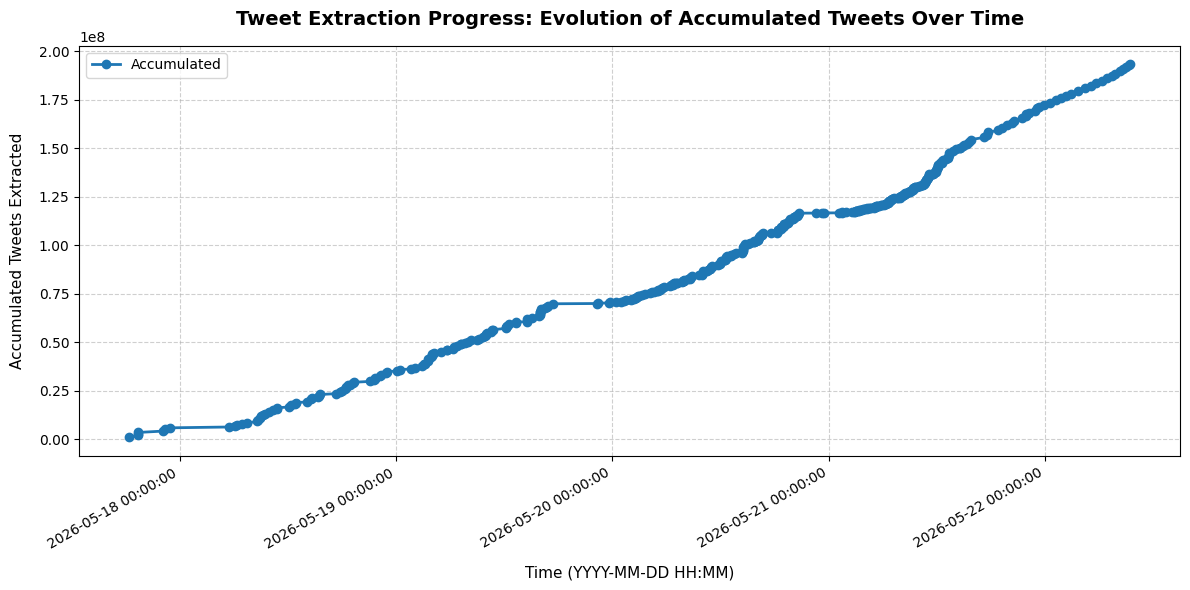

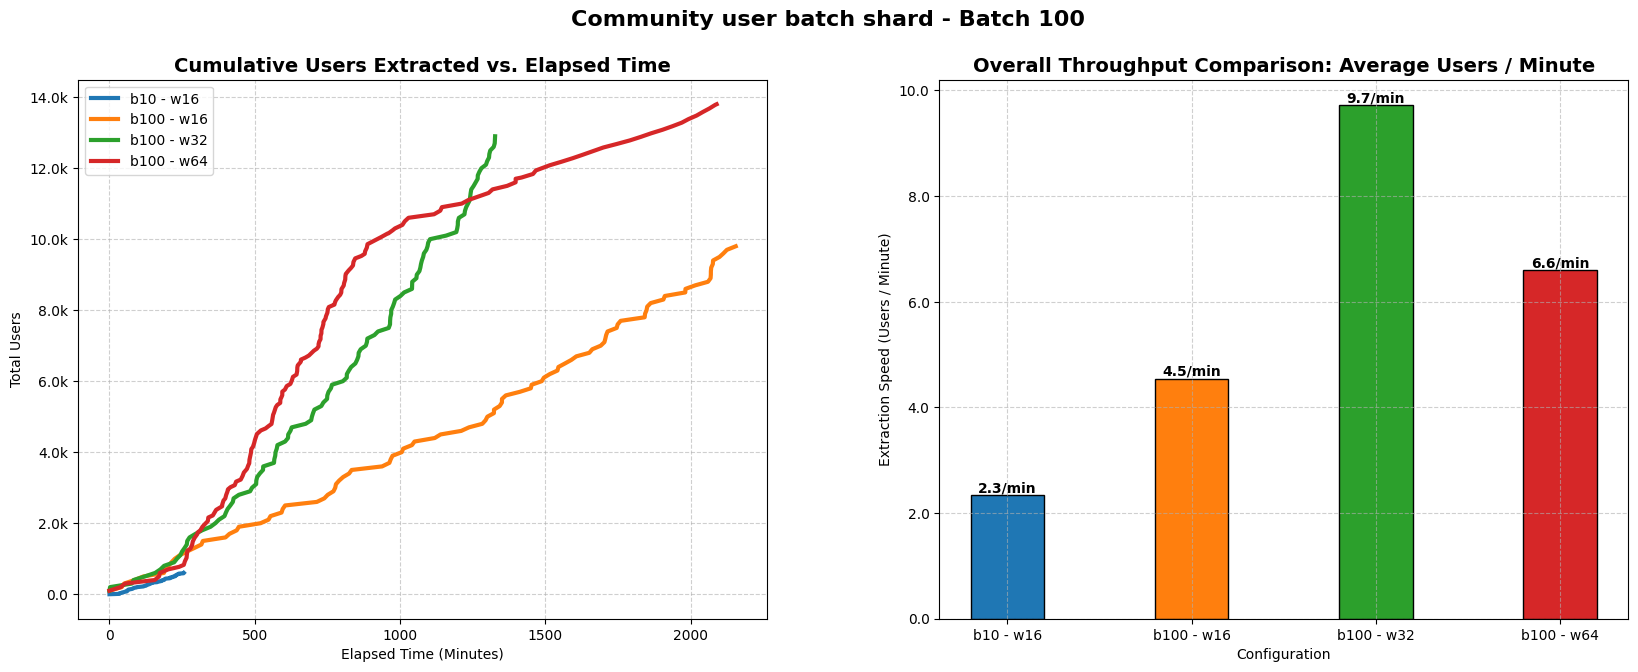

📊 EXTRACTION COMPARISON REPORT: COMMUNITY USER BATCH SHARD - BATCH 100
Run / Configuration                      | Users      | Duration (min)  | Speed (Users/min) 
------------------------------------------------------------------------------------------
b10 - w16                                | 600        | 255m 54s        | 2.34              
b100 - w16                               | 9,800      | 2155m 39s       | 4.55              
b100 - w32                               | 12,898     | 1327m 24s       | 9.72              
b100 - w64                               | 13,801     | 2089m 58s       | 6.60              
------------------------------------------------------------------------------------------


In [12]:
import os
from utils import (
    plot_extraction_dashboard,
    plot_extraction_progress,
    plot_community_distribution,
    analyze_user_id_distribution,
    plot_community_id_distribution,
    plot_id_distribution_bands,
    calculate_optimal_user_ranges,
    plot_extraction_comparison
)

# --- EXECUTION ---
# Make sure LOG_DATA_BATCH_500 and LOG_DATA_BATCH_5000 are defined before running
# plot_extraction_dashboard('tweets-sorted-by-user-batch-500-(users-diagram).txt', "All tweets sorted by user - Batch 500")
# plot_extraction_progress('tweets-sorted-by-user-batch-500-(tweets-diagram).txt')
# plot_extraction_dashboard('tweets-sorted-by-user-batch-5000-(users-diagram).txt', "All tweets sorted by user - Batch 5000")
# plot_extraction_progress('tweets-sorted-by-user-batch-5000-(tweets-diagram).txt')

# plot_extraction_dashboard('community-shard-aware-batch-10-(users-diagram).txt', "Community user batch shard - Batch 10")
# plot_extraction_progress('community-shard-aware-batch-10-(tweets-diagram).txt')
# plot_extraction_dashboard('community-shard-aware-batch-100-(users-diagram).txt', "Community user batch shard - Batch 100")
plot_extraction_progress('community-shard-aware-batch-100-(tweets-diagram).txt')
runs_to_compare = [
    {
        "path": "community-shard-aware-batch-10-(users-diagram).txt", 
        "label": "b10 - w16"
    },
    {
        "path": "community-shard-aware-batch-100-16workers-(users-diagram).txt", 
        "label": "b100 - w16"
    },
    {
        "path": "community-shard-aware-batch-100-32workers-(users-diagram).txt", 
        "label": "b100 - w32"
    },
    {
        "path": "community-shard-aware-batch-100-64workers-(users-diagram).txt", 
        "label": "b100 - w64"
    }
]
plot_extraction_comparison(runs_to_compare, title="Community user batch shard - Batch 100", max_minutes=100000)

# plot_extraction_dashboard('community-linear-batch-10-(users-diagram).txt', "Community user batch linear - Batch 10")
# plot_extraction_progress('community-linear-batch-10-(tweets-diagram).txt')

# plot_community_distribution(os.path.join('..', '..', 'resources', 'communities_rp_0.4.csv'))



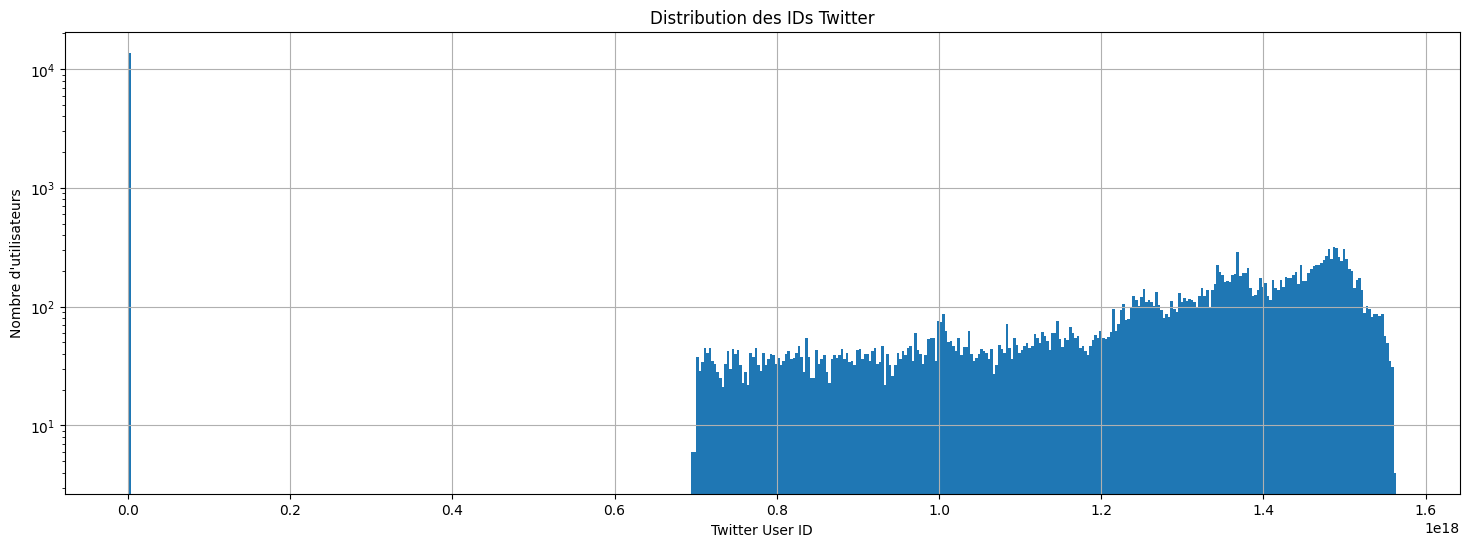


=== DENSE USER ID RANGES ===

Cluster   Users     Range Size               Min ID                   Max ID
-----------------------------------------------------------------------------------------------
0         13758     4927053403               505083                   4927558486
1         20        966030566400000          716491802933596160       717457833499996160
2         20        914323484598273          783574940616228864       784489264100827137
3         21        1091086764150785         795764425697488896       796855512461639681
4         33        1661583004475393         824926881384452096       826588464388927489
5         20        831502371844097          828223254250786816       829054756622630913
6         50        2428200395231233         836126586483113984       838554786878345217
7         21        852909323460609          897077656507863040       897930565831323649
8         20        919530498969602          900242237329727488       901161767828697090
9  

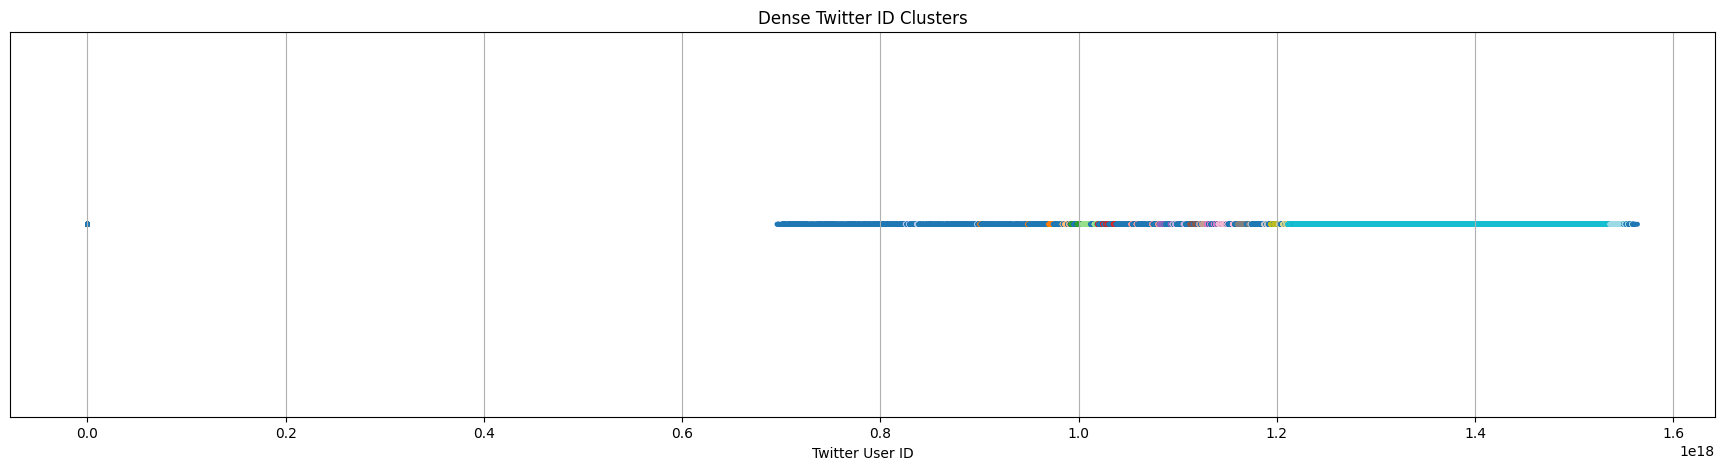

In [10]:
import os
from utils import (
    plot_extraction_dashboard,
    plot_extraction_progress,
    plot_community_distribution,
    analyze_user_id_distribution,
    plot_community_id_distribution,
    plot_id_distribution_bands,
    calculate_optimal_user_ranges,
    plot_user_distribution,
    detect_dense_id_ranges
)

GLOBAL_DB_MIN_UID = 59        
GLOBAL_DB_MAX_UID = 1615058741384122396  
# GLOBAL_DB_MAX_UID = 100000000
path_csv = csv_path=os.path.join('..', '..', 'resources', 'communities_rp_0.4.csv')

# df_dist = analyze_user_id_distribution(
#     path_csv, 
#     n_workers=1, 
#     global_min=GLOBAL_DB_MIN_UID, 
#     global_max=GLOBAL_DB_MAX_UID
# )

# plot_community_id_distribution(path_csv, 20, GLOBAL_DB_MIN_UID, GLOBAL_DB_MAX_UID)

# plot_id_distribution_bands(path_csv, 20, GLOBAL_DB_MIN_UID, GLOBAL_DB_MAX_UID)

# calculate_optimal_user_ranges(path_csv, 2000, GLOBAL_DB_MIN_UID, GLOBAL_DB_MAX_UID)
plot_user_distribution(path_csv)

ranges = detect_dense_id_ranges(
    path_csv,
    # eps=1e15,
    eps=0.5e15,
    min_samples=20
)